# Paso 5: Preparación de Datos para Modelamiento y SMOTE

Este notebook implementa el **Paso 5** del pipeline para la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Codificar las etiquetas categóricas** a valores numéricos usando `LabelEncoder` y guardar la correspondencia.
2. **División de datos**: Separar el dataset en conjuntos de entrenamiento (80%) y prueba (20%) de forma estratificada.
3. **Garantizar la validez metodológica**: Aislar el conjunto de prueba y guardarlo sin alteraciones.
4. **Balanceo de clases con SMOTE**: Aplicar SMOTE **únicamente en el conjunto de entrenamiento** y sobre las clases hiper-minoritarias (`Web-based` y `Brute Force`) de forma controlada y optimizada en memoria.
5. **Visualización de distribución**: Comparar la distribución de clases en el conjunto de entrenamiento antes y después del SMOTE.

In [1]:
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

# Configuración de estilo gráfico premium
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs("results/figures", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar dataset mapeado generado en el Paso 4
df_path = "data/processed/dataset_mapeado.csv"
print("Cargando dataset mapeado...")
df = pd.read_csv(df_path)
print(f"¡Cargado con éxito! Filas: {len(df):,}, Columnas: {df.shape[1]}")

Cargando dataset mapeado...
¡Cargado con éxito! Filas: 2,515,882, Columnas: 37


## 1. Codificación de Variable Objetivo (LabelEncoder)

In [3]:
# Inicializar LabelEncoder
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

# Guardar el diccionario de mapeo
label_mapping = dict(zip(le.classes_, map(int, range(len(le.classes_)))))
print("Mapeo de categorías a enteros:")
for k, v in label_mapping.items():
    print(f"  - {k} -> {v}")

# Guardar el mapeo en formato JSON para uso futuro en evaluación
with open("results/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)
print("Mapeo guardado en 'results/label_mapping.json'")

# Reemplazar la columna Label por la codificada
df.drop(columns=['Label'], inplace=True)
df.rename(columns={'Label_encoded': 'Label'}, inplace=True)

Mapeo de categorías a enteros:
  - Benign -> 0
  - Brute Force -> 1
  - DDoS -> 2
  - DoS -> 3
  - Mirai -> 4
  - Recon -> 5
  - Spoofing -> 6
  - Web-based -> 7
Mapeo guardado en 'results/label_mapping.json'


## 2. División de Datos en Entrenamiento (Train) y Prueba (Test) - 80/20

In [4]:
# Separar variables independientes (X) y objetivo (y)
X = df.drop(columns=['Label'])
y = df['Label']

# División estratificada para mantener las proporciones en train y test
print("Realizando partición de datos Train/Test estratificada (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"Conjunto de Prueba: {X_test.shape[0]:,} muestras")

# Guardar inmediatamente el conjunto de prueba (debe quedar puro, libre de SMOTE)
print("Guardando conjunto de prueba...")
X_test.to_csv("data/processed/X_test.csv", index=False)
y_test.to_csv("data/processed/y_test.csv", index=False)
print("¡Conjunto de prueba guardado en data/processed/!")

Realizando partición de datos Train/Test estratificada (80/20)...
Conjunto de Entrenamiento: 2,012,705 muestras
Conjunto de Prueba: 503,177 muestras
Guardando conjunto de prueba...
¡Conjunto de prueba guardado en data/processed/!


## 3. Balanceo de Clases con SMOTE (Únicamente en el Conjunto de Entrenamiento)

Para evitar un sobremuestreo excesivo que agote la RAM y aumente innecesariamente el tiempo de entrenamiento de XGBoost/LightGBM, aplicamos una **estrategia de SMOTE selectiva**:
* Incrementamos las muestras de `Web-based` a 100,000 registros.
* Incrementamos las muestras de `Brute Force` a 100,000 registros.
* Mantenemos el resto de las clases en su tamaño original.

In [5]:
class_names = le.classes_

print("Distribución original en Entrenamiento:")
original_train_counts = y_train.value_counts().sort_index()
for idx, count in original_train_counts.items():
    print(f"  - {class_names[idx]} (clase {idx}): {count:,} ({count/len(y_train)*100:.2f}%)")

# Identificar códigos numéricos de las clases minoritarias
web_idx = label_mapping['Web-based']
brute_idx = label_mapping['Brute Force']

# Estrategia de SMOTE personalizada
smote_strategy = {
    web_idx: 100000,
    brute_idx: 100000
}

print(f"\nAplicando SMOTE con la siguiente estrategia: {smote_strategy}...")
smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribución final en Entrenamiento tras SMOTE:")
resampled_train_counts = y_train_res.value_counts().sort_index()
for idx, count in resampled_train_counts.items():
    print(f"  - {class_names[idx]} (clase {idx}): {count:,} ({count/len(y_train_res)*100:.2f}%)")

Distribución original en Entrenamiento:
  - Benign (clase 0): 100,220 (4.98%)
  - Brute Force (clase 1): 10,016 (0.50%)
  - DDoS (clase 2): 791,866 (39.34%)
  - DoS (clase 3): 277,040 (13.76%)
  - Mirai (clase 4): 295,654 (14.69%)
  - Recon (clase 5): 331,985 (16.49%)
  - Spoofing (clase 6): 186,958 (9.29%)
  - Web-based (clase 7): 18,966 (0.94%)

Aplicando SMOTE con la siguiente estrategia: {7: 100000, 1: 100000}...

Distribución final en Entrenamiento tras SMOTE:
  - Benign (clase 0): 100,220 (4.59%)
  - Brute Force (clase 1): 100,000 (4.58%)
  - DDoS (clase 2): 791,866 (36.26%)
  - DoS (clase 3): 277,040 (12.69%)
  - Mirai (clase 4): 295,654 (13.54%)
  - Recon (clase 5): 331,985 (15.20%)
  - Spoofing (clase 6): 186,958 (8.56%)
  - Web-based (clase 7): 100,000 (4.58%)


## 4. Guardar Conjunto de Entrenamiento Balanceado

In [6]:
print("Guardando conjunto de entrenamiento balanceado...")
X_train_res.to_csv("data/processed/X_train_resampled.csv", index=False)
y_train_res.to_csv("data/processed/y_train_resampled.csv", index=False)
print("¡Conjunto de entrenamiento guardado exitosamente en data/processed/!")

Guardando conjunto de entrenamiento balanceado...
¡Conjunto de entrenamiento guardado exitosamente en data/processed/!


## 5. Visualización del Balanceo de Clases

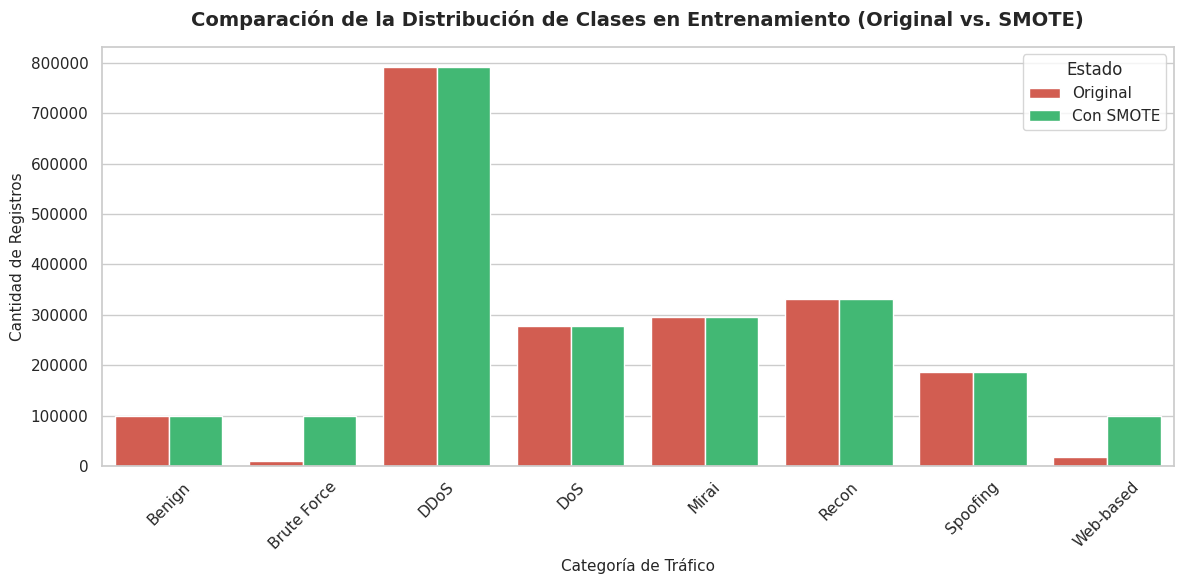

In [7]:
# Crear DataFrame de comparación para graficar
indices = range(len(class_names))
labels = [class_names[i] for i in indices]

df_plot = pd.DataFrame({
    'Clase': labels * 2,
    'Cantidad': list(original_train_counts) + list(resampled_train_counts),
    'Estado': ['Original'] * len(labels) + ['Con SMOTE'] * len(labels)
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Clase', y='Cantidad', hue='Estado', palette=['#E74C3C', '#2ECC71'])
plt.title("Comparación de la Distribución de Clases en Entrenamiento (Original vs. SMOTE)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoría de Tráfico", fontsize=11)
plt.ylabel("Cantidad de Registros", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/figures/07_distribucion_smote.png", dpi=300)
plt.show()